In [1]:
import h5py
import rioxarray
import xarray as xr
import numpy as np
from scipy.ndimage import gaussian_filter

In [2]:
los_path = "../products/nisar/nisar_20251213_20251225_los_vel_dmodel.tif"

h5_path = (
    "/mnt/storage/brencher/repos/jirp_nisar_eval/data/nisar/"
    "NISAR_L2_PR_GUNW_007_135_A_031_008_4000_SH_"
    "20251213T132334_20251213T132409_"
    "20251225T132334_20251225T132410_"
    "X05010_N_F_J_001.h5"
)

dem_path = (
    "/mnt/storage/brencher/repos/jirp_nisar_eval/data/cop30/"
    "cop_30m.tif"
)

In [3]:
los_vel = (
    rioxarray.open_rasterio(los_path, masked=True)
    .squeeze("band", drop=True)
    .rename("los_velocity")
)

In [4]:
dem = (
    rioxarray.open_rasterio(dem_path, masked=True)
    .squeeze("band", drop=True)
    .rename("elevation")
)

In [5]:
dem_match = dem.rio.reproject_match(los_vel)

In [6]:
ds = xr.Dataset(
    {
        "los_velocity": los_vel,
        "elevation": dem_match,
    }
)

In [7]:
geometry_keywords = [
    "incidence",
    "azimuth",
    "heading",
    "look",
    "los",
    "projection",
    "xcoordinates",
    "ycoordinates",
]


with h5py.File(h5_path, "r") as f:

    def print_geometry_datasets(name, obj):
        if isinstance(obj, h5py.Dataset):
            name_lower = name.lower()

            if any(keyword in name_lower for keyword in geometry_keywords):
                print(
                    f"{name}\n"
                    f"    shape: {obj.shape}\n"
                    f"    dtype: {obj.dtype}"
                )

    f.visititems(print_geometry_datasets)

science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/projection
    shape: ()
    dtype: uint32
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/xCoordinateSpacing
    shape: ()
    dtype: float64
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/xCoordinates
    shape: (4743,)
    dtype: float64
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/yCoordinateSpacing
    shape: ()
    dtype: float64
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/HH/yCoordinates
    shape: (4734,)
    dtype: float64
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/projection
    shape: ()
    dtype: uint32
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/xCoordinateSpacing
    shape: ()
    dtype: float64
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/xCoordinates
    shape: (4743,)
    dtype: float64
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/yCoordinateSpacing
    shape: ()
    dtype: float64
science/LSAR/GUNW/grids/frequencyA/pixelOffsets/yCoordinates
    shape: (4734,)
    dtype: float64
science

In [8]:
ds_crop = ds.rio.clip_box(
    minx=490079,
    miny=6466981,
    maxx=586441,
    maxy=6567768,
)

ds_crop = ds_crop.where(np.isfinite(ds_crop.elevation))

In [9]:
ds_crop = ds_crop.dropna(dim="x", how="all")

In [10]:
sigma_m = 100

dx = abs(float(ds_crop.x[1] - ds_crop.x[0]))
dy = abs(float(ds_crop.y[1] - ds_crop.y[0]))

sigma_x = sigma_m / dx
sigma_y = sigma_m / dy

print("Pixel size:", dx, dy)
print("Gaussian sigma in pixels:", sigma_x, sigma_y)

Pixel size: 20.0 20.0
Gaussian sigma in pixels: 5.0 5.0


In [11]:
dem_np = ds_crop["elevation"].values.astype(float)

valid = np.isfinite(dem_np)

dem_filled = np.where(valid, dem_np, 0.0)
weights = valid.astype(float)

dem_smooth_num = gaussian_filter(
    dem_filled,
    sigma=(sigma_y, sigma_x),
)

dem_smooth_den = gaussian_filter(
    weights,
    sigma=(sigma_y, sigma_x),
)

dem_smooth_np = np.divide(
    dem_smooth_num,
    dem_smooth_den,
    out=np.full_like(dem_smooth_num, np.nan),
    where=dem_smooth_den > 0,
)

# Restore the original DEM footprint
dem_smooth_np[~valid] = np.nan

In [12]:
ds_crop["elevation_smooth"] = xr.DataArray(
    dem_smooth_np,
    coords=ds_crop["elevation"].coords,
    dims=ds_crop["elevation"].dims,
    attrs={
        "long_name": "Smoothed elevation",
        "units": "m",
        "smoothing_sigma_m": sigma_m,
    },
)

In [13]:
dz_dy, dz_dx = np.gradient(
    dem_smooth_np,
    ds_crop.y.values,
    ds_crop.x.values,
)

In [14]:
ds_crop["dz_dx"] = xr.DataArray(
    dz_dx,
    coords=ds_crop["elevation"].coords,
    dims=ds_crop["elevation"].dims,
)

ds_crop["dz_dy"] = xr.DataArray(
    dz_dy,
    coords=ds_crop["elevation"].coords,
    dims=ds_crop["elevation"].dims,
)

slope_rad = np.arctan(np.hypot(dz_dx, dz_dy))

ds_crop["slope"] = xr.DataArray(
    np.degrees(slope_rad),
    coords=ds_crop["elevation"].coords,
    dims=ds_crop["elevation"].dims,
    attrs={
        "long_name": "Surface slope",
        "units": "degrees",
    },
)

In [15]:
p = ds_crop["dz_dx"]  # dz / dEast
q = ds_crop["dz_dy"]  # dz / dNorth

grad_mag = np.hypot(p, q)

In [16]:
min_slope = np.tan(np.deg2rad(0.5))

downslope_e = xr.where(
    grad_mag > min_slope,
    -p / grad_mag,
    np.nan,
)

downslope_n = xr.where(
    grad_mag > min_slope,
    -q / grad_mag,
    np.nan,
)

In [17]:
cos_slope = 1.0 / np.sqrt(1.0 + grad_mag**2)
sin_slope = grad_mag / np.sqrt(1.0 + grad_mag**2)

ds_crop["downslope_e"] = downslope_e * cos_slope
ds_crop["downslope_n"] = downslope_n * cos_slope
ds_crop["downslope_u"] = -sin_slope

In [18]:
downslope_norm = np.sqrt(
    ds_crop["downslope_e"]**2
    + ds_crop["downslope_n"]**2
    + ds_crop["downslope_u"]**2
)

print(
    downslope_norm.quantile(
        [0.01, 0.5, 0.99],
        skipna=True,
    ).values
)

[1. 1. 1.]


In [19]:
with h5py.File(h5_path, "r") as f:

    def show_geometry(name, obj):
        if not isinstance(obj, h5py.Dataset):
            return

        key = name.lower()

        if any(
            term in key
            for term in [
                "incidence",
                "azimuth",
                "losunit",
                "look",
                "elevationangle",
            ]
        ):
            print("\n", name)
            print("  shape:", obj.shape)
            print("  dtype:", obj.dtype)

            for attr_name, attr_value in obj.attrs.items():
                print(f"  {attr_name}: {attr_value}")

    f.visititems(show_geometry)


 science/LSAR/GUNW/metadata/processingInformation/algorithms/interferogramFormation/multilooking
  shape: ()
  dtype: |S38
  description: b'Multilooking algorithm'

 science/LSAR/GUNW/metadata/processingInformation/parameters/geocoding/azimuthIonosphericCorrectionApplied
  shape: ()
  dtype: |S4
  description: b'Flag to indicate if the azimuth ionospheric correction is applied to improve geolocation'

 science/LSAR/GUNW/metadata/processingInformation/parameters/reference/frequencyA/azimuthBandwidth
  shape: ()
  dtype: float64
  description: b'Processed azimuth bandwidth for reference RSLC'
  units: b'hertz'

 science/LSAR/GUNW/metadata/processingInformation/parameters/reference/frequencyA/numberOfAzimuthLines
  shape: ()
  dtype: uint64
  description: b'Number of azimuth lines within the reference RSLC'
  units: b'1'

 science/LSAR/GUNW/metadata/processingInformation/parameters/secondary/frequencyA/azimuthBandwidth
  shape: ()
  dtype: float64
  description: b'Processed azimuth bandw

In [20]:
radar_grid_path = "/science/LSAR/GUNW/metadata/radarGrid"

with h5py.File(h5_path, "r") as f:
    for name, obj in f[radar_grid_path].items():
        if isinstance(obj, h5py.Dataset):
            print(name, obj.shape)

alongTrackUnitVectorX (20, 769, 771)
alongTrackUnitVectorY (20, 769, 771)
elevationAngle (20, 769, 771)
groundTrackVelocity (20, 769, 771)
heightAboveEllipsoid (20,)
hydrostaticTroposphericPhaseScreen (20, 769, 771)
incidenceAngle (20, 769, 771)
losUnitVectorX (20, 769, 771)
losUnitVectorY (20, 769, 771)
parallelBaseline (20, 769, 771)
perpendicularBaseline (20, 769, 771)
projection ()
referenceSlantRange (20, 769, 771)
referenceZeroDopplerAzimuthTime (20, 769, 771)
secondarySlantRange (20, 769, 771)
secondaryZeroDopplerAzimuthTime (20, 769, 771)
slantRangeSolidEarthTidesPhase (20, 769, 771)
wetTroposphericPhaseScreen (20, 769, 771)
xCoordinates (771,)
yCoordinates (769,)


In [21]:
with h5py.File(h5_path, "r") as f:
    g = f[radar_grid_path]

    geom_x = g["xCoordinates"][:]
    geom_y = g["yCoordinates"][:]
    geom_h = g["heightAboveEllipsoid"][:]

    los_e = g["losUnitVectorX"][:]
    los_n = g["losUnitVectorY"][:]

In [22]:
geom = xr.Dataset(
    {
        "los_e": (
            ("height", "y", "x"),
            los_e,
        ),
        "los_n": (
            ("height", "y", "x"),
            los_n,
        ),
    },
    coords={
        "height": geom_h,
        "y": geom_y,
        "x": geom_x,
    },
)

In [23]:
geom = geom.sortby("height").sortby("y").sortby("x")

In [24]:
geom_xy = geom.interp(
    x=ds_crop.x,
    y=ds_crop.y,
)

In [25]:
heights = geom_xy.height.values
surface_h = ds_crop["elevation_smooth"].values

los_e_stack = geom_xy["los_e"].values
los_n_stack = geom_xy["los_n"].values

In [26]:
upper = np.searchsorted(heights, surface_h)

upper = np.clip(upper, 1, len(heights) - 1)
lower = upper - 1

In [27]:
h0 = heights[lower]
h1 = heights[upper]

w = (surface_h - h0) / (h1 - h0)

In [28]:
rows, cols = np.indices(surface_h.shape)

los_e0 = los_e_stack[lower, rows, cols]
los_e1 = los_e_stack[upper, rows, cols]

los_n0 = los_n_stack[lower, rows, cols]
los_n1 = los_n_stack[upper, rows, cols]

In [29]:
los_e_surface = los_e0 + w * (los_e1 - los_e0)
los_n_surface = los_n0 + w * (los_n1 - los_n0)

In [30]:
valid = np.isfinite(surface_h)

los_e_surface[~valid] = np.nan
los_n_surface[~valid] = np.nan

In [31]:
ds_crop["los_e"] = xr.DataArray(
    los_e_surface,
    coords=ds_crop["elevation_smooth"].coords,
    dims=ds_crop["elevation_smooth"].dims,
)

ds_crop["los_n"] = xr.DataArray(
    los_n_surface,
    coords=ds_crop["elevation_smooth"].coords,
    dims=ds_crop["elevation_smooth"].dims,
)

In [32]:
ds_crop["los_u"] = np.sqrt(
    np.maximum(
        0,
        1 - ds_crop["los_e"]**2 - ds_crop["los_n"]**2,
    )
)

In [33]:
los_horizontal_sq = (
    ds_crop["los_e"]**2
    + ds_crop["los_n"]**2
)

ds_crop["los_u"] = np.sqrt(
    np.maximum(0, 1 - los_horizontal_sq)
)

In [34]:
los_norm = np.sqrt(
    ds_crop["los_e"]**2
    + ds_crop["los_n"]**2
    + ds_crop["los_u"]**2
)

print(
    los_norm.quantile(
        [0.01, 0.5, 0.99],
        skipna=True,
    ).values
)

[1. 1. 1.]


In [35]:
for var in ["los_e", "los_n", "los_u"]:
    print(
        var,
        ds_crop[var].quantile(
            [0.01, 0.5, 0.99],
            skipna=True,
        ).values,
    )

los_e [0.52677332 0.56260176 0.59374519]
los_n [0.23496023 0.25923575 0.28184289]
los_u [0.7537083  0.78502477 0.81686352]


In [36]:
los_sensitivity = (
    ds_crop["downslope_e"] * ds_crop["los_e"]
    + ds_crop["downslope_n"] * ds_crop["los_n"]
    + ds_crop["downslope_u"] * ds_crop["los_u"]
)

ds_crop["los_sensitivity"] = los_sensitivity

In [37]:
ds_crop["slope_parallel_velocity"] = (
    -ds_crop["los_velocity"] / ds_crop["los_sensitivity"]
)

In [38]:
min_sensitivity = 0.2

ds_crop["slope_parallel_velocity"] = (
    ds_crop["slope_parallel_velocity"]
    .where(np.abs(ds_crop["los_sensitivity"]) >= min_sensitivity)
)

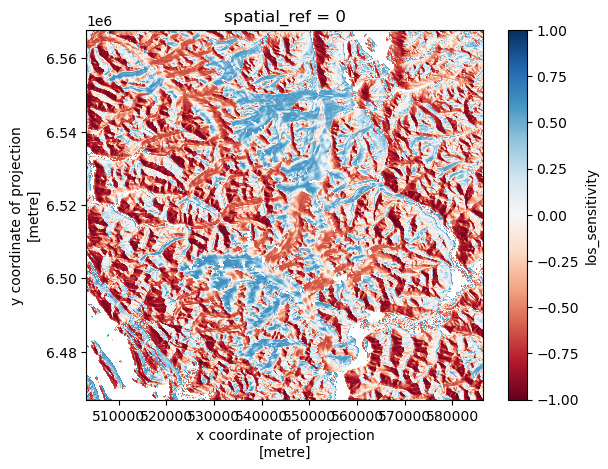

In [39]:
ds_crop["los_sensitivity"].plot(
    vmin=-1,
    vmax=1,
    cmap="RdBu",
)

In [40]:
import matplotlib.pyplot as plt

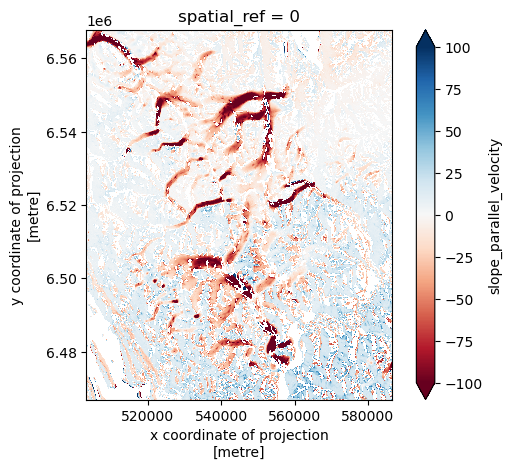

In [41]:
f, ax = plt.subplots()
ds_crop["slope_parallel_velocity"].plot(
    ax=ax,
    vmax=100,
    vmin=-100,
    cmap="RdBu",
)
ax.set_aspect(1)

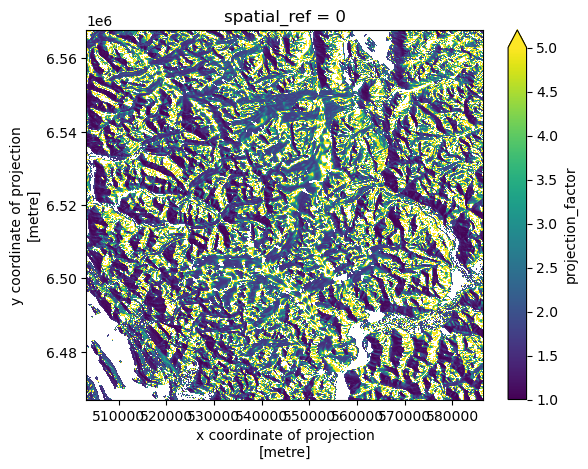

In [42]:
ds_crop["projection_factor"] = 1 / np.abs(ds_crop["los_sensitivity"])

ds_crop["projection_factor"].where(
    ds_crop["projection_factor"] <= 10
).plot(vmin=1, vmax=5)

In [43]:
out_path = (
    "../products/nisar/"
    "nisar_20251213_20251225_slope_parallel_vel.tif"
)

out = ds_crop["slope_parallel_velocity"].astype("float32")

out.attrs.update(
    {
        "long_name": "Slope-parallel downslope velocity",
        "units": ds_crop["los_velocity"].attrs.get("units", "unknown"),
        "projection_assumption": (
            "Velocity is parallel to the smoothed DEM surface "
            "and directed downslope"
        ),
        "minimum_absolute_los_sensitivity": min_sensitivity,
    }
)

out.rio.write_nodata(np.nan, inplace=True)
out.rio.to_raster(out_path)